# ☕ Cafe Sales Data Analysis
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Cafe transaction records  
**Goal:** Analyze sales patterns across time, products, and store locations

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Preparation

In [14]:
df = pd.read_excel("Coffee Shop Sales (Month).xlsx")
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df["days"] = pd.to_datetime(df["transaction_date"]).dt.day
df['revenue'] = df['unit_price'] * df['transaction_qty']
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
df['day_of_week'] = df['transaction_date'].dt.day_name()
df['month'] = df['transaction_date'].dt.month_name()
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,days,revenue,hour,day_of_week,month
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,1,6.0,7,Sunday,January
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1,6.2,7,Sunday,January
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,1,9.0,7,Sunday,January
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,1,2.0,7,Sunday,January
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1,6.2,7,Sunday,January


## 2. Time Analysis

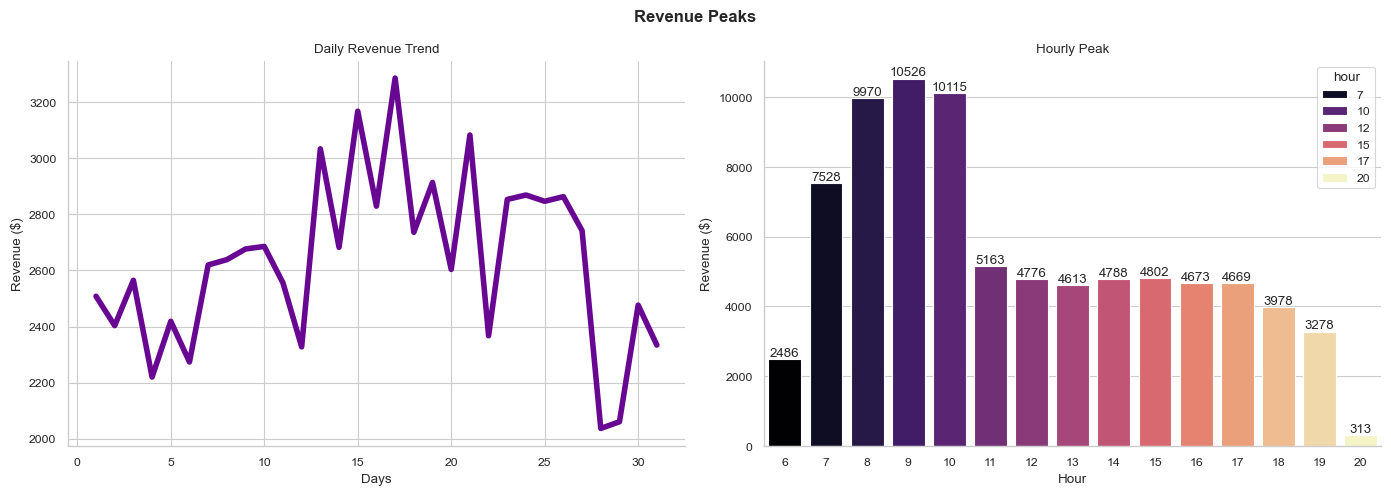

In [ ]:
sns.set_theme(style="whitegrid" , context="paper")

fig , axs = plt.subplots(1,2, figsize=(14,5))
fig.suptitle("Revenue Peaks" ,fontsize=12 , fontweight="bold")

# ════ DAILY SALES ════
daily = df.groupby("days")["revenue"].sum().reset_index()
sns.lineplot(data=daily , x="days" , y="revenue" , ax=axs[0] , color="#680791" , linewidth=4)
axs[0].set_title("Daily Revenue Trend")
axs[0].set_xlabel("Days")
axs[0].set_ylabel("Revenue ($)")

# ════ HOURLY PEAL ════
hourly = df.groupby("hour")["revenue"].sum().reset_index()
sns.barplot(data=hourly , x="hour" , y="revenue" , ax=axs[1] , palette="magma" ,hue="hour")
axs[1].set_title("Hourly Peak")
axs[1].set_xlabel("Hour")
axs[1].set_ylabel("Revenue ($)")

for ax in axs.flat:
    sns.despine(ax=ax)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=0)

plt.tight_layout()
plt.savefig('time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Product Analysis 

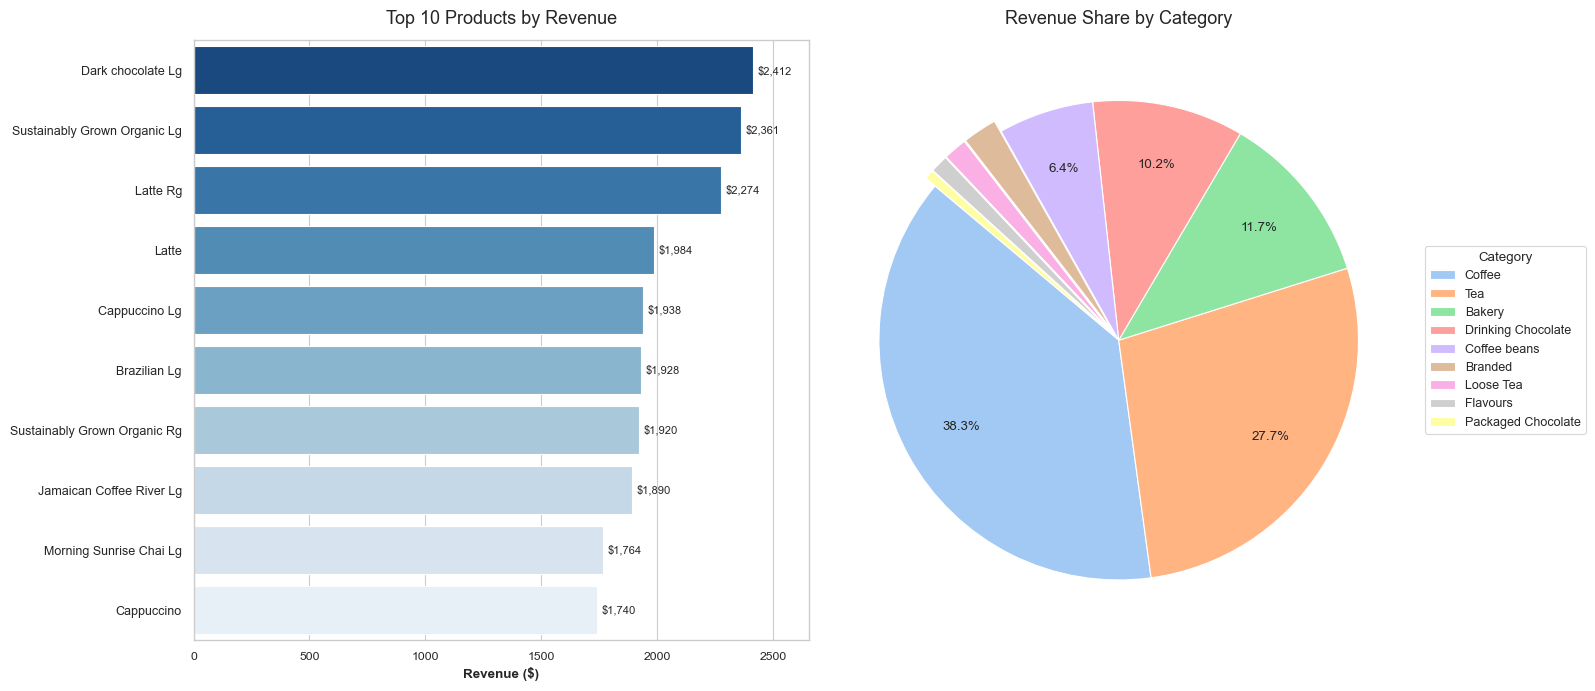

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# ════ TOP PRODUCTS ════
top_products = df.groupby('product_detail')['revenue'].sum().nlargest(10).reset_index()
sns.barplot(
    data=top_products, 
    y='product_detail', 
    x='revenue', 
    ax=axes[0], 
    palette='Blues_r',
    hue="product_detail",
    legend=False)

axes[0].set_xlim(0, top_products['revenue'].max() * 1.1)  # 15% extra space on the right
axes[0].set_title('Top 10 Products by Revenue', fontsize=13, pad=12)
axes[0].set_xlabel('Revenue ($)' , fontweight="bold")
axes[0].set_ylabel('')
axes[0].tick_params(axis='y', labelsize=9)  # to make names smaller

# writing Revenue amount near each Bar
for i, row in top_products.iterrows():
    axes[0].text(row['revenue'] + 20, i, f"${row['revenue']:,.0f}", va='center', fontsize=8)

# ════ SHARE OF CATEGORIES ════ 
category_rev = df.groupby('product_category')['revenue'].sum().reset_index()
category_rev = category_rev.sort_values('revenue', ascending=False)

values = list(category_rev['revenue'])
labels = list(category_rev['product_category'])
colors = sns.color_palette('pastel', len(values))

# Separating small batches from the pie for better readability
explode = [0.05 if v / sum(values) < 0.05 else 0 for v in values]

wedges, texts, autotexts = axes[1].pie(
    values,
    labels=None,           # removing Labels from pie
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',  # not to write lower precentages
    colors=colors,
    explode=explode,
    startangle=140,
    pctdistance=0.75
)

# Separate Legend = More readability
axes[1].legend(
    wedges, labels,
    title='Category',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9
)
axes[1].set_title('Revenue Share by Category', fontsize=13, pad=12)

plt.tight_layout()
plt.savefig('product_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Heatmap  

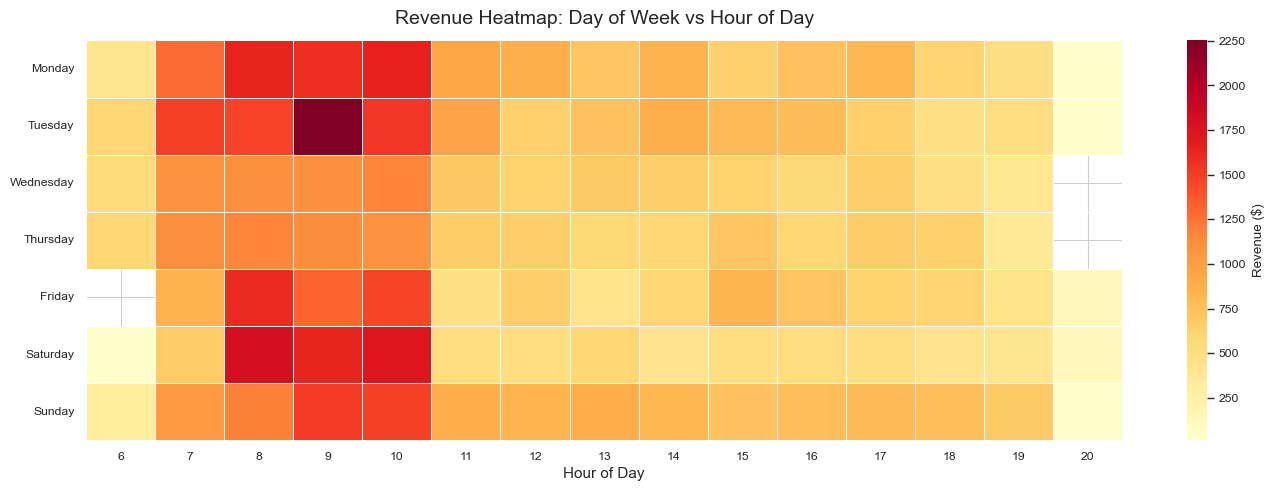

In [ ]:


# ════ CREATING PIVOT TABLE ════
pivot = df.pivot_table(
    values='revenue',
    index='day_of_week',
    columns='hour',
    aggfunc='sum'
)

# ════ SORTING WEEKDAYS ════
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    # -- more cmap options : (viridis / blues / coolwarm) --
    linewidths=0.5,
    linecolor='white',
    annot=False,
    # -- annot=true : writes number in every square (only for small tables)
    cbar_kws={'label': 'Revenue ($)'}
)
plt.title('Revenue Heatmap: Day of Week vs Hour of Day', fontsize=14, pad=12)
plt.xlabel('Hour of Day', fontsize=11)
plt.ylabel('')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Branch Comparison  

C:\Users\sxna\AppData\Local\Temp\ipykernel_18640\1514862918.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(


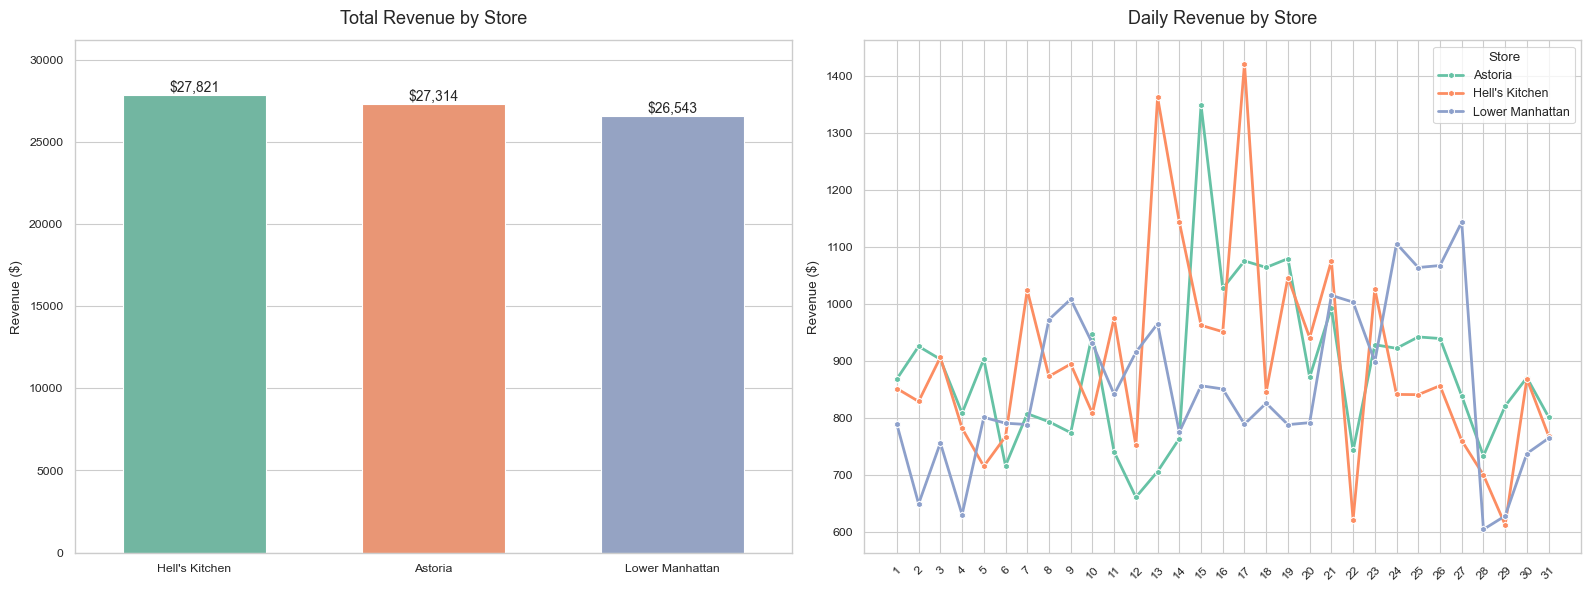

In [ ]:

sns.set_style("whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# ════ REVENUE OF EACH BRANCH ════
branch_total = df.groupby('store_location')['revenue'].sum().reset_index()
branch_total = branch_total.sort_values('revenue', ascending=False)

sns.barplot(
    data=branch_total,
    x='store_location',
    y='revenue',
    hue='store_location',
    palette='Set2',
    legend=False,
    width=0.6,
    ax=axs[0]
)
axs[0].set_title('Total Revenue by Store', fontsize=13, pad=12)
axs[0].set_xlabel('')
axs[0].set_ylabel('Revenue ($)')
axs[0].set_xlim(-0.5, len(branch_total) - 0.5)

# ════ NUMBERS ABOVE THE BAR ════
for i, row in branch_total.iterrows():
    axs[0].text(
        list(branch_total['store_location']).index(row['store_location']),
        row['revenue'] + 200,
        f"${row['revenue']:,.0f}",
        # -- number format ($12,345)
        ha='center', fontsize=10, fontweight='500'
        # -- (ha = horizontal alignment)
    )
axs[0].set_ylim(0, branch_total['revenue'].max() * 1.12)

# ════ BRANCHES MONTHLY TREND ════
branch_daily = df.groupby(['store_location', df['days']])['revenue'].sum().reset_index()
branch_daily['days'] = branch_daily['days'].astype(str)

sns.lineplot(
    data=branch_daily,
    x='days',
    y='revenue',
    hue='store_location',
    marker="h",
    linewidth=2,
    palette='Set2',
    ax=axs[1]
)

axs[1].set_title('Daily Revenue by Store', fontsize=13, pad=12)
axs[1].set_xlabel('')
axs[1].set_ylabel('Revenue ($)')
axs[1].tick_params(axis='x', rotation=45)
axs[1].legend(title='Store', fontsize=9)

axes[1].legend(
    title='Store',           # title above the legend
    fontsize=9,              
    loc='upper left',        
    bbox_to_anchor=(1, 1),   # put it out of chart
    framealpha=0.5           # legend backgrounds transparency
)

plt.tight_layout()
plt.savefig('branch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Key Insights

- ⏰ **Peak Hours:** Highest sales between *8* and *10 a.m.*
- 🏆 **Top Product:** The Best-selling Product is *Dark chocolate Lg* with *$2,412* Sales in a Month
- 📍 **Best Store:** Branch *Hell's Kitchen* with total Revenue of *$27,821* in a Month 
- 📅 **Best Day:** *Tuesdays* have the highest Sales